In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [96]:
df = pd.read_excel("../DataSets/Clinical Dataset.xlsx")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [98]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


In [99]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate IDs:", df["id"].duplicated().sum())

Missing values: 0
Duplicate rows: 0
Duplicate IDs: 0


In [100]:
categorical_features = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active"
]

for feature in categorical_features:
    print(f"\n{feature}:")
    print(df[feature].value_counts().sort_index())


gender:
gender
1    45530
2    24470
Name: count, dtype: int64

cholesterol:
cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

gluc:
gluc
1    59479
2     5190
3     5331
Name: count, dtype: int64

smoke:
smoke
0    63831
1     6169
Name: count, dtype: int64

alco:
alco
0    66236
1     3764
Name: count, dtype: int64

active:
active
0    13739
1    56261
Name: count, dtype: int64


In [101]:
print("Cardiovascular Disease Distribution:")
print(df["cardio"].value_counts())

print("\nPercentage Distribution:")
print(
    (df["cardio"].value_counts(normalize=True) * 100).round(2)
)

Cardiovascular Disease Distribution:
cardio
0    35021
1    34979
Name: count, dtype: int64

Percentage Distribution:
cardio
0    50.03
1    49.97
Name: proportion, dtype: float64


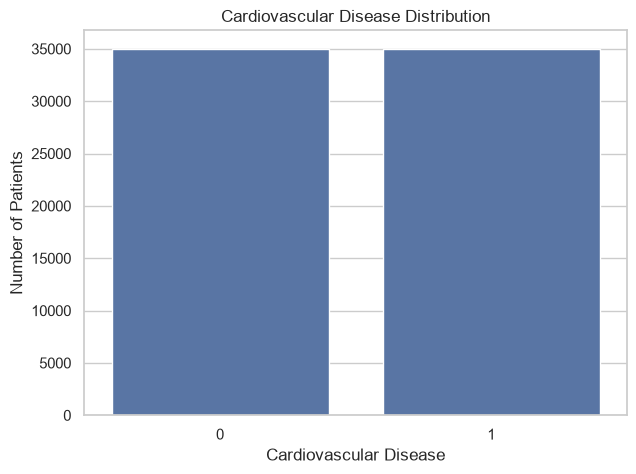

In [102]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="cardio")

plt.title("Cardiovascular Disease Distribution")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Number of Patients")
plt.show()

In [103]:
numerical_features = [
    "age",
    "height",
    "weight",
    "ap_hi",
    "ap_lo"
]

display(df[numerical_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
age,70000.0,19468.865814,2467.251667,10798.0,17664.0,19703.0,21327.0,23713.0
height,70000.0,164.359229,8.210126,55.0,159.0,165.0,170.0,250.0
weight,70000.0,74.205690,14.395757,10.0,65.0,72.0,82.0,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.0,120.0,140.0,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.0,80.0,90.0,11000.0


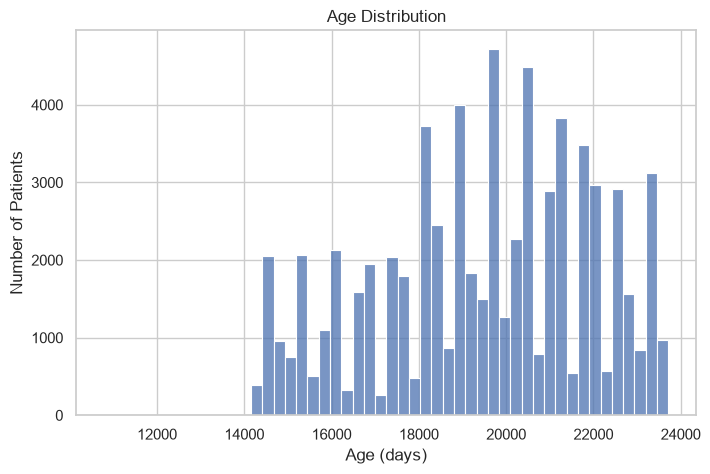

In [104]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="age", bins=50)

plt.title("Age Distribution")
plt.xlabel("Age (days)")
plt.ylabel("Number of Patients")
plt.show()

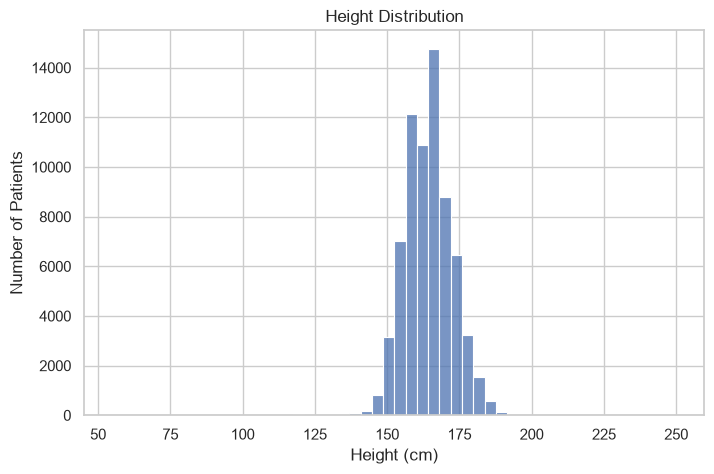

In [105]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="height", bins=50)

plt.title("Height Distribution")
plt.xlabel("Height (cm)")
plt.ylabel("Number of Patients")
plt.show()

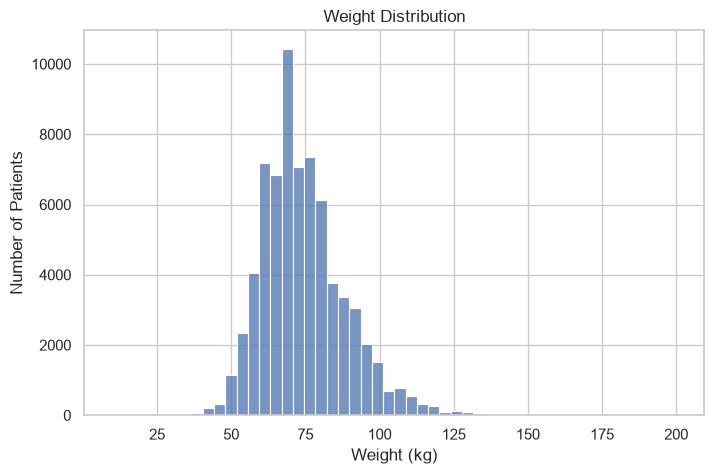

In [106]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="weight", bins=50)

plt.title("Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Number of Patients")
plt.show()

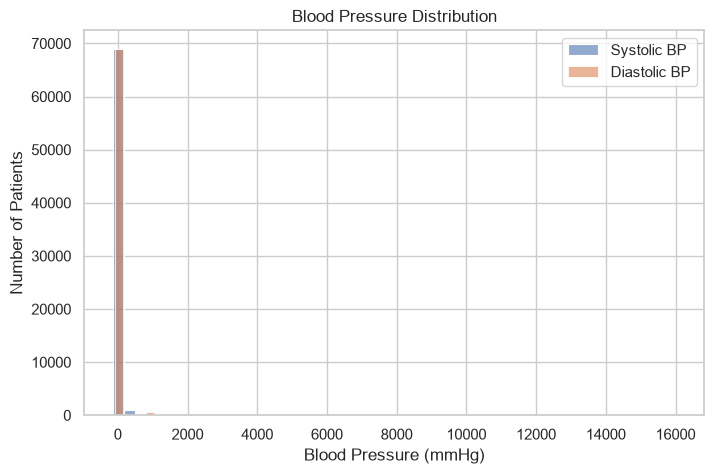

In [107]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="ap_hi",
    bins=50,
    label="Systolic BP",
    alpha=0.6
)

sns.histplot(
    data=df,
    x="ap_lo",
    bins=50,
    label="Diastolic BP",
    alpha=0.6
)

plt.title("Blood Pressure Distribution")
plt.xlabel("Blood Pressure (mmHg)")
plt.ylabel("Number of Patients")
plt.legend()
plt.show()

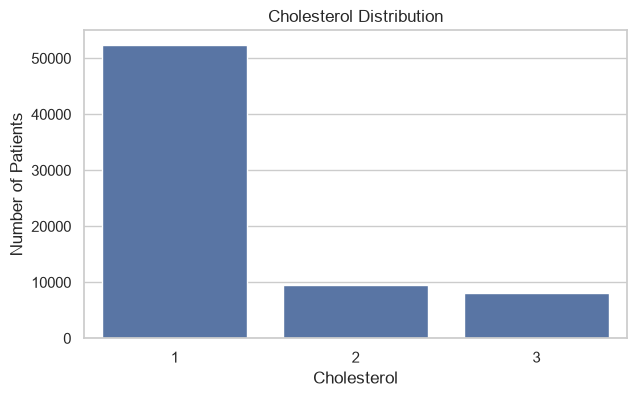

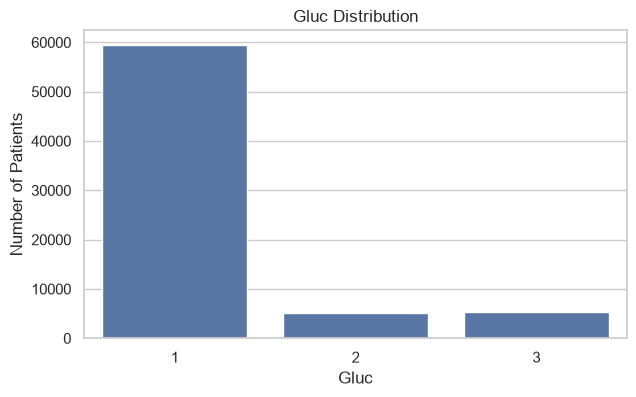

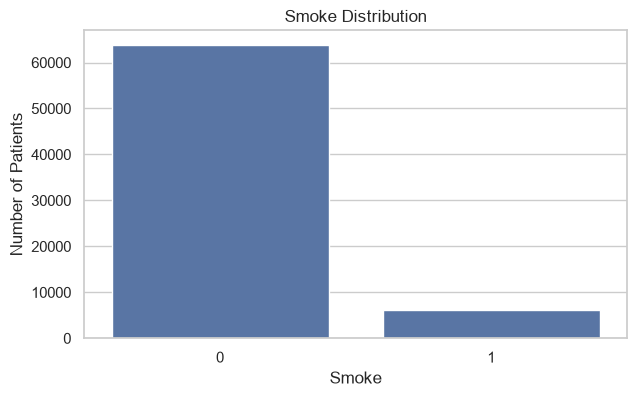

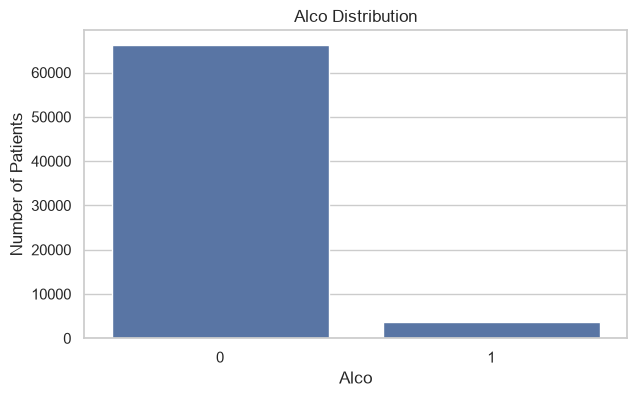

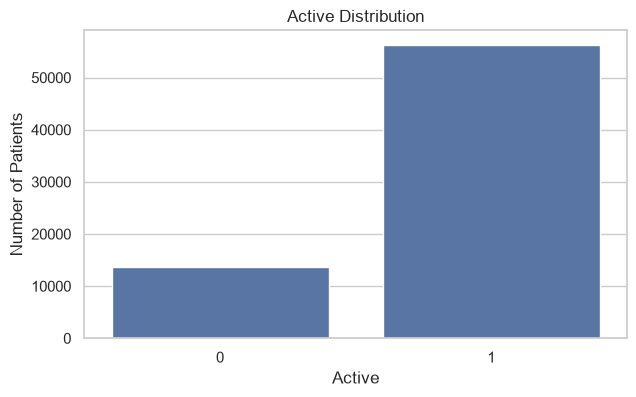

In [108]:
for feature in ["cholesterol", "gluc", "smoke", "alco", "active"]:
    
    plt.figure(figsize=(7, 4))
    
    sns.countplot(data=df, x=feature)
    
    plt.title(f"{feature.capitalize()} Distribution")
    plt.xlabel(feature.capitalize())
    plt.ylabel("Number of Patients")
    plt.show()

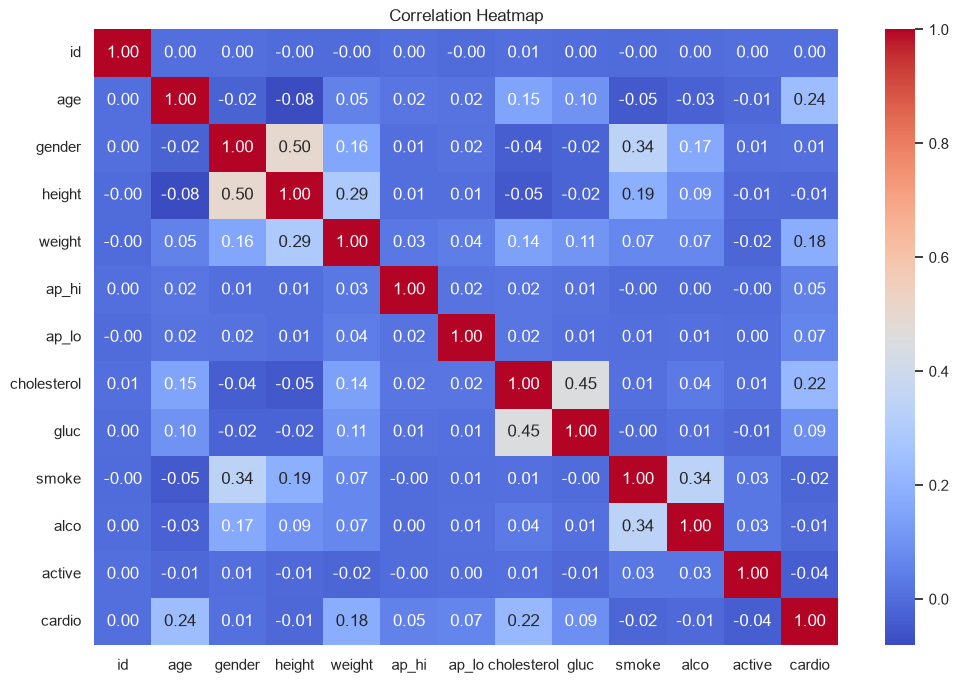

In [109]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

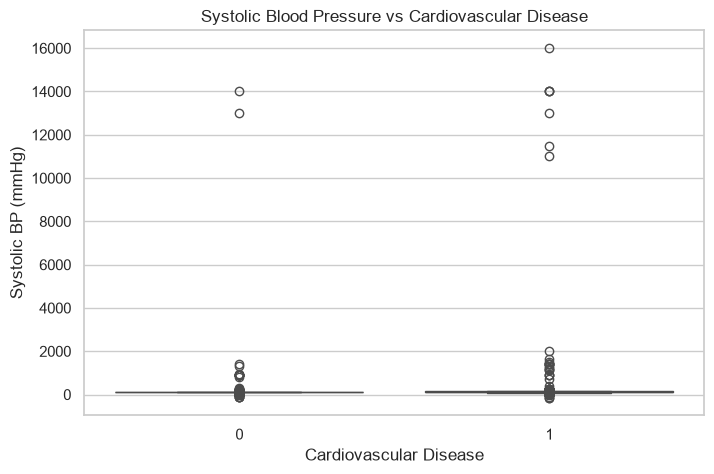

In [110]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="cardio",
    y="ap_hi"
)

plt.title("Systolic Blood Pressure vs Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Systolic BP (mmHg)")
plt.show()

In [111]:
cholesterol_cvd = pd.crosstab(
    df["cholesterol"],
    df["cardio"],
    normalize="index"
) * 100

display(cholesterol_cvd.round(2))

cardio,0,1
cholesterol,,
1,55.99,44.01
2,39.78,60.22
3,23.46,76.54


In [112]:
print("Blood Pressure Validation")
print("-------------------------")

print("Systolic BP <= 0:", (df["ap_hi"] <= 0).sum())
print("Diastolic BP <= 0:", (df["ap_lo"] <= 0).sum())
print("Systolic BP > 300:", (df["ap_hi"] > 300).sum())
print("Diastolic BP > 200:", (df["ap_lo"] > 200).sum())
print("Systolic BP <= Diastolic BP:", (df["ap_hi"] <= df["ap_lo"]).sum())

print("\nHeight and Weight Validation")
print("----------------------------")

print("Height < 100 cm:", (df["height"] < 100).sum())
print("Height > 220 cm:", (df["height"] > 220).sum())
print("Weight < 30 kg:", (df["weight"] < 30).sum())
print("Weight > 200 kg:", (df["weight"] > 200).sum())

Blood Pressure Validation
-------------------------
Systolic BP <= 0: 7
Diastolic BP <= 0: 22
Systolic BP > 300: 40
Diastolic BP > 200: 953
Systolic BP <= Diastolic BP: 1236

Height and Weight Validation
----------------------------
Height < 100 cm: 29
Height > 220 cm: 1
Weight < 30 kg: 7
Weight > 200 kg: 0


In [113]:
df_clean = df.copy()

valid_records = (
    (df_clean["ap_hi"] > 0) &
    (df_clean["ap_lo"] > 0) &
    (df_clean["ap_hi"] <= 300) &
    (df_clean["ap_lo"] <= 200) &
    (df_clean["ap_hi"] > df_clean["ap_lo"]) &
    (df_clean["height"] >= 100) &
    (df_clean["height"] <= 220) &
    (df_clean["weight"] >= 30) &
    (df_clean["weight"] <= 200)
)

df_clean = df_clean[valid_records].copy()

print("Original records:", len(df))
print("Cleaned records:", len(df_clean))
print("Records removed:", len(df) - len(df_clean))

Original records: 70000
Cleaned records: 68675
Records removed: 1325


In [114]:
df_clean["age_years"] = df_clean["age"] / 365.25

df_clean["BMI"] = (
    df_clean["weight"] /
    ((df_clean["height"] / 100) ** 2)
)

df_clean["pulse_pressure"] = (
    df_clean["ap_hi"] - df_clean["ap_lo"]
)

df_clean["MAP"] = (
    df_clean["ap_hi"] + 2 * df_clean["ap_lo"]
) / 3

model_df = df_clean.drop(
    columns=["id", "age"]
).copy()

X = model_df.drop(columns=["cardio"])
y = model_df["cardio"]

print("Final Dataset Shape:", model_df.shape)
display(model_df.head())

Final Dataset Shape: (68675, 15)


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,BMI,pulse_pressure,MAP
0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290,21.967120,30,90.000000
1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246,34.927679,50,106.666667
2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652,23.507805,60,90.000000
3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144,28.710479,50,116.666667
4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205,23.011177,40,73.333333
